In [25]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

# Dados dos Top 20 de cada modelo
model_data = {
    "KNN": [
        ("Genótipos", "Semeadura_dia", 0.017623, 0.000000), ("NH.RAD > 800", "NH.RAD > 600", 0.014151, 0.000000),
        ("ND.UR > 80", "Semeadura_dia", 0.012889, 0.000000), ("Fung. Plan", "ND.PREC > 5", 0.011421, 0.000000),
        ("Genótipos", "Colheita_mes", 0.010209, 0.000000), ("Temp. Ar Mín", "Temp. Ar Noturna", 0.009875, 0.000000),
        ("Temp. Orvalho", "NH.UR > 90", 0.009585, 0.000000), ("ND.TMIN < 10", "Gen. Propósito", 0.008690, 0.000000),
        ("Evapo. PM", "ND.RAD < 10", 0.008431, 0.000000), ("Solo Grupo", "Temp. Ar Mín", 0.008175, 0.000000),
        ("UR Mínima", "Ciclo Sem-Col", 0.007368, 0.000000), ("Talhão", "Colheita [dec]", 0.006219, 0.000000),
        ("Gen. Propósito", "Temp. Orvalho", 0.005940, 0.000000), ("ND.RAD > 20", "Semeadura_mes", 0.005870, 0.000000),
        ("Gen. Propósito", "Temp. Ar [soma]", 0.005815, 0.000000), ("Graus Dias", "ND.UR > 80", 0.005694, 0.000000),
        ("Temp. Orvalho", "Semeadura_dia", 0.005601, 0.000000), ("Temp. Ar [soma]", "NH.UR > 90", 0.005409, 0.000000),
        ("Gen. Propósito", "NH.RAD > 800", 0.004924, 0.000000), ("Temp. Ar Mín", "ND.TMAX > 30", 0.004749, 0.000000)
    ],
    "DT": [
        ("ND.PREC > 5", "Colheita_dia", 0.074921, -0.009475), ("NH.TMED < 10", "Temp. Orvalho", 0.062874, 0.000000),
        ("Gen. Propósito", "Semeadura_dia", 0.048638, 0.000000), ("Genótipos", "Alt. Média [m]", 0.046660, 0.000000),
        ("NH.TMED < 10", "ND.UR > 90", 0.044089, 0.000000), ("Temp. Ar", "Semeadura_dia", 0.041252, 0.000000),
        ("Solo Grupo", "Alt. Média [m]", 0.041246, 0.000000), ("Solo Textura", "Temp. Ar", 0.039881, 0.000000),
        ("Amp. Térmica", "Alt. Mínima", 0.037516, 0.000000), ("Precipitação", "UR Mínima", 0.036859, 0.000000),
        ("Temp. Orvalho", "Colheita_ano", 0.036757, 0.000000), ("NH.RAD > 800", "ND.RAD > 20", 0.035520, 0.000000),
        ("Temp. Ar", "Semeadura_ano", 0.032107, 0.000000), ("Fotoperiodo", "Fung. Plan", 0.031603, 0.000000),
        ("Alt. Máxima", "ND.PREC > 0.2", 0.027912, 0.000000), ("Alt. Máxima", "Semeadura [dec]", 0.025955, 0.000000),
        ("Tipo Safra", "Temp. Ar", 0.025740, 0.000000), ("NH.UR > 90", "NH.UR < 60", 0.025273, 0.000000),
        ("Gen. Propósito", "Temp. Ar Noturna", 0.024204, 0.000000), ("UR Mínima", "ND.TMAX > 30", 0.023737, 0.000000)
    ],
    "RF": [
        ("UR Máxima", "NH.UR < 60", 0.003664, 0.000000), ("Alt. Máxima", "Semeadura [dec]", 0.003427, 0.000000),
        ("Fotoperiodo", "ND.UR < 60", 0.003002, 0.000000), ("Gen. Propósito", "Temp. Ar Máx", 0.002975, 0.000000),
        ("UR Mínima", "NH.RAD > 800", 0.002947, 0.000000), ("Precipitação", "Temp. Ar", 0.002805, 0.000000),
        ("Evapo. PM", "Colheita_dia", 0.002699, 0.000000), ("Rad. Solar", "Alt. Mínima", 0.002493, 0.000000),
        ("UR [soma]", "Rad. Solar", 0.002378, 0.000000), ("Fotoperiodo", "Genótipos", 0.002271, 0.000000),
        ("Precipitação", "Rad. Solar", 0.002179, 0.000000), ("Ciclo Sem-Col", "ND.TMAX > 30", 0.002122, 0.000000),
        ("ND.RAD > 20", "Colheita_dia", 0.002116, 0.000000), ("UR Mínima", "Colheita_dia", 0.001783, 0.000000),
        ("ND.TMIN < 10", "Amp. Térmica", 0.001748, 0.000000), ("NH.TMED < 10", "Solo Textura", 0.001649, -0.000097),
        ("Colheita [dec]", "ND.PREC > 5", 0.001613, 0.000000), ("Evapo. PM", "NH.RAD > 1000", 0.001605, 0.000000),
        ("Gen. Propósito", "Semeadura_mes", 0.001576, 0.000000), ("Temp. Ar Mín", "Ciclo Sem-Col", 0.001574, 0.000000)
    ],
    "MLP": [
        ("Temp. Ar Noturna", "Fung. Plan", 0.066809, 0.000000), ("ND.TMAX > 30", "Semeadura_mes", 0.061263, 0.000000),
        ("NH.TMED < 10", "NH.UR < 60", 0.055489, 0.000000), ("NH.UR < 60", "Semeadura_dia", 0.054138, 0.000000),
        ("ND.TMIN < 10", "Solo Textura", 0.048643, 0.000000), ("UF", "NH.UR < 60", 0.046791, 0.000000),
        ("ND.PREC > 0.2", "ND.RAD > 20", 0.043698, -0.009301), ("Solo Textura", "Semeadura [dec]", 0.042917, 0.000000),
        ("NH.TMED < 10", "UR [soma]", 0.042081, 0.000000), ("Gen. Propósito", "Semeadura_mes", 0.040592, 0.000000),
        ("Colheita [dec]", "NH.RAD > 800", 0.040327, 0.000000), ("Graus Dias", "UR [soma]", 0.039895, 0.000000),
        ("NH.UR > 90", "ND.PREC > 0.2", 0.037338, 0.000000), ("Graus Dias", "Temp. Molhamento", 0.035399, 0.000000),
        ("Gen. Propósito", "Precipitação", 0.034528, 0.000000), ("Solo Grupo", "Temp. Orvalho", 0.030881, 0.000000),
        ("Gen. Propósito", "ND.PREC = 0.0", 0.030746, 0.000000), ("Amp. Térmica", "Alt. Máxima", 0.029471, 0.000000),
        ("NH.UR > 90", "Semeadura [dec]", 0.028816, 0.000000), ("Temp. Ar Máx", "Precipitação", 0.027080, 0.000000)
    ]
}

In [26]:
def plot_interaction_graph(model_name, interactions):
    G = nx.Graph()
    
    # AJUSTE AQUI: Desempacotando 4 valores e calculando a média
    for u, v, v_max, v_min in interactions:
        v_med = (v_max + v_min) / 2
        G.add_edge(u, v, weight=v_med)
    
    plt.figure(figsize=(14, 12))
    
    pos = nx.circular_layout(G)
    
    # Extrair pesos médios para largura e cor
    weights = [G[u][v]['weight'] for u, v in G.edges()]
    abs_weights = [abs(w) for w in weights]
    
    # Normalização para largura (escala 1 a 10)
    max_w = max(abs_weights) if max(abs_weights) > 0 else 1
    edge_widths = [(w / max_w) * 8 + 0.5 for w in abs_weights]
    
    # Cor baseada no sinal da média (Vermelho + | Azul -)
    edge_colors = ['tomato' if G[u][v]['weight'] > 0 else 'royalblue' for u, v in G.edges()]
    
    # Desenhar Nodos (Azul Claro)
    nx.draw_networkx_nodes(G, pos, node_size=1000, node_color='skyblue', alpha=1.0, edgecolors='grey')
    
    # Desenhar Arestas
    nx.draw_networkx_edges(G, pos, width=edge_widths, edge_color=edge_colors, alpha=0.6)
    
    # Desenhar Labels (Nomes)
    nx.draw_networkx_labels(G, pos, font_size=8, font_family='sans-serif', font_weight='bold')
    
    # Labels com os valores médios
    #edge_labels = {(u, v): f'{G[u][v]["weight"]:.3f}' for u, v in G.edges()}
    #nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7)
    
    plt.title(f"VIG - Interação Média: {model_name}", fontsize=10, pad=20)
    plt.axis('off')
    plt.show()

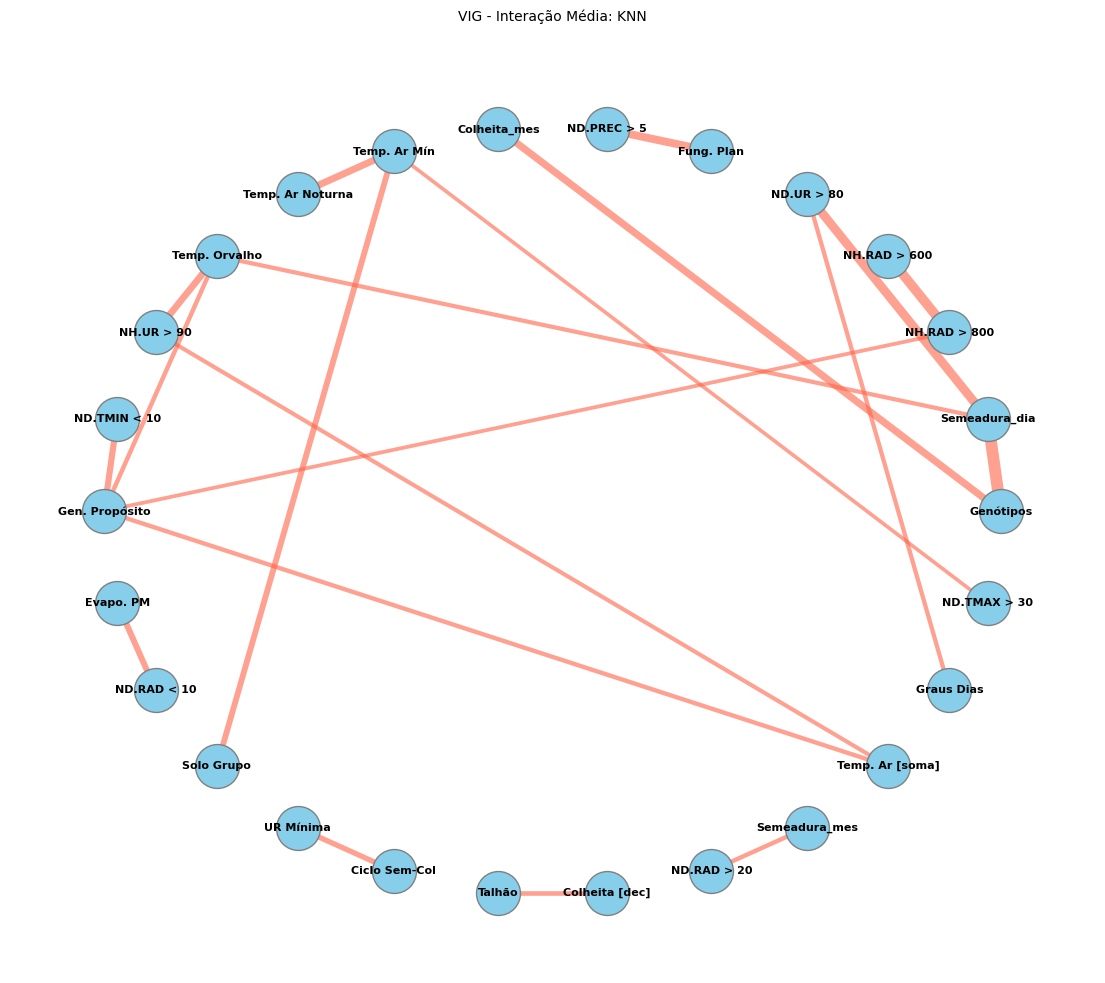

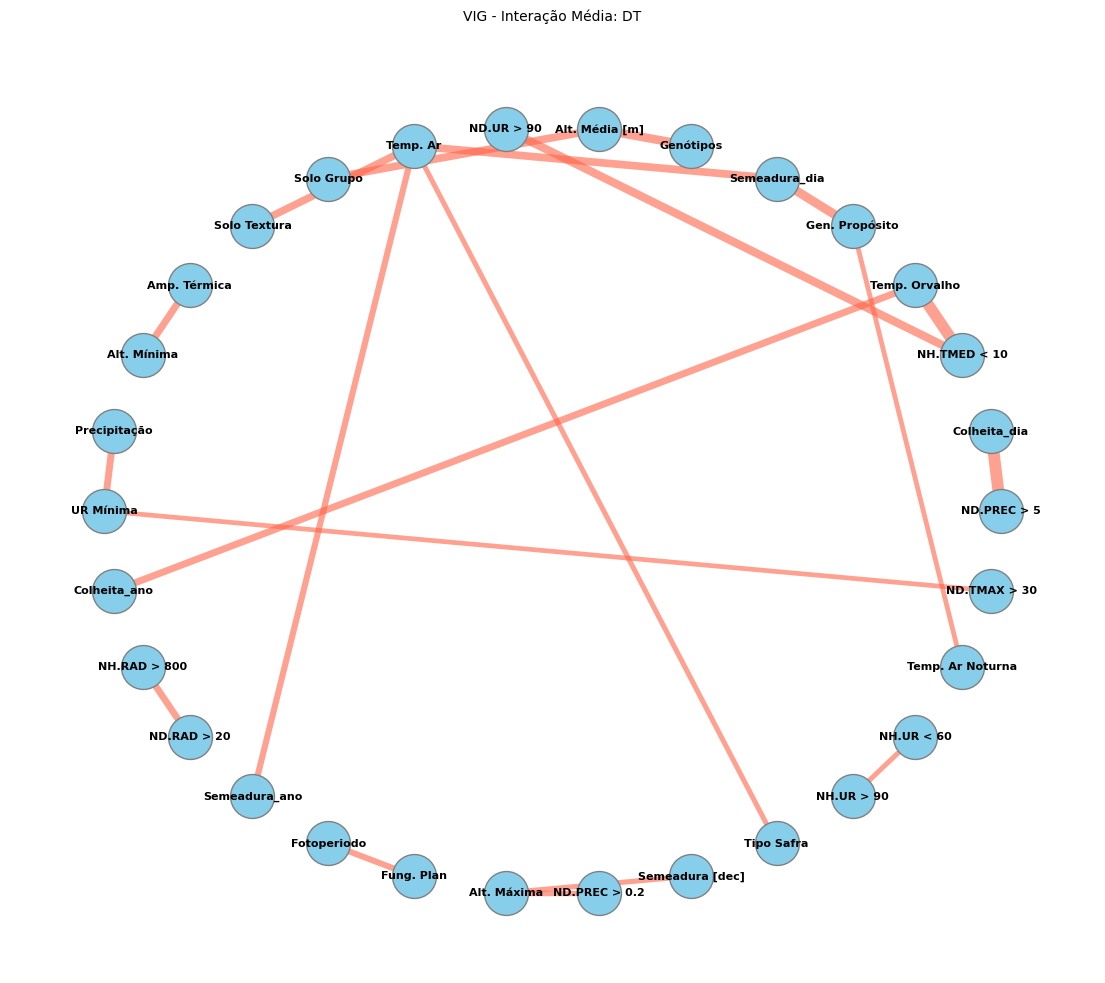

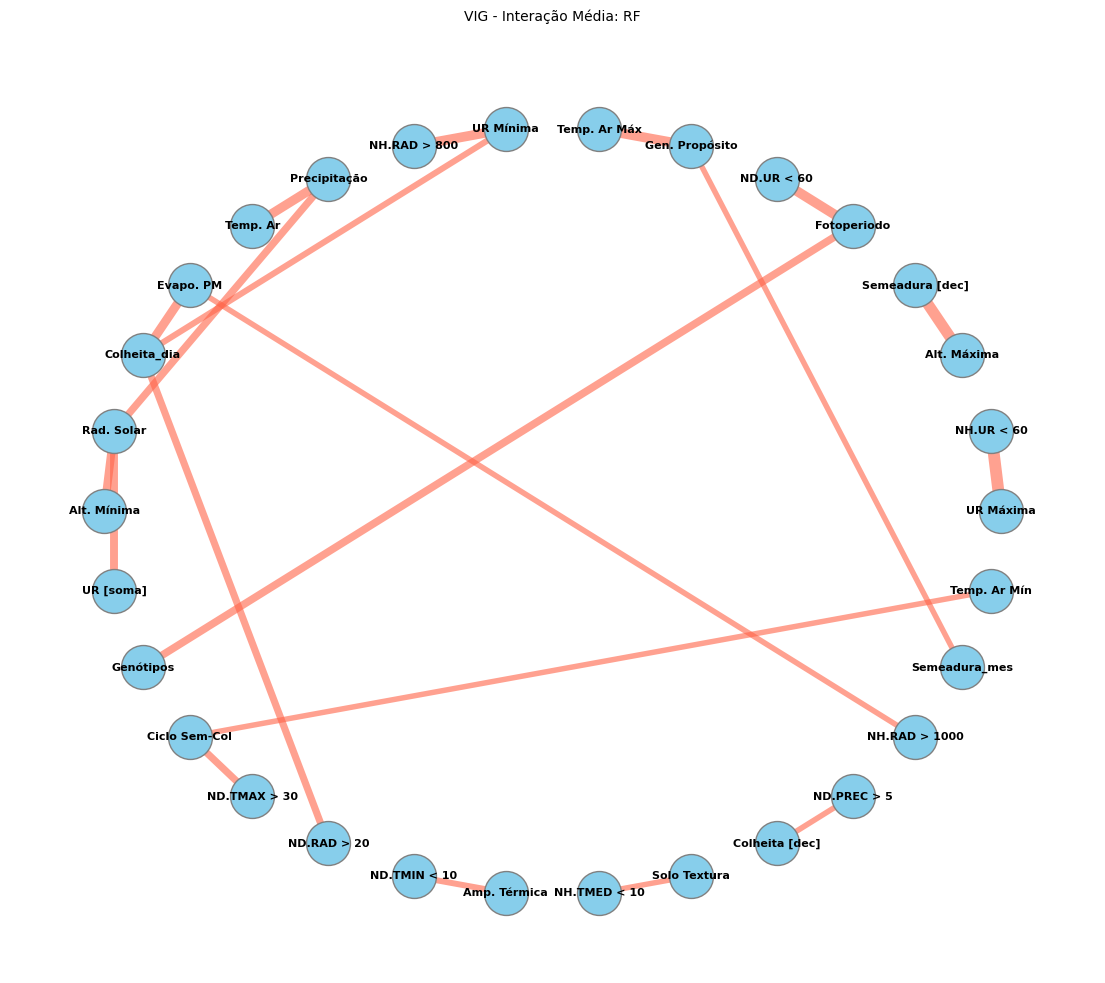

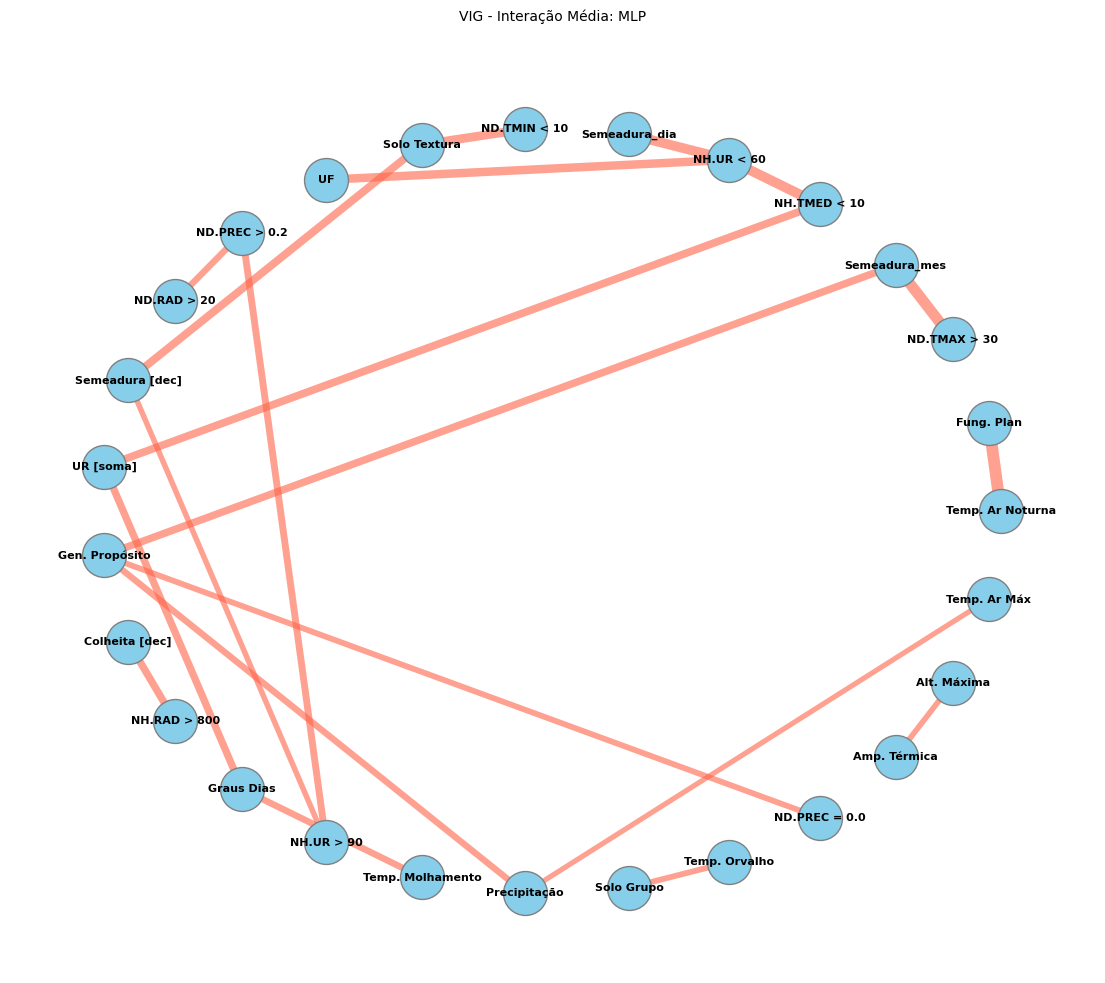

In [27]:
for model, interactions in model_data.items():
    plot_interaction_graph(model, interactions)